### ==============================================================================
## Processing of Moving Vessel Profiler Data - code 1
### Authors: Elisabet Verger-Miralles (everger@imedea.uib-csic.es)
### Data from FaSt-SWOT experiment
# 
**DESCRIPTION**:
This script performs Step 1 Quality Control (QC) specifically on the profiles
selected during Step 0.2. It reads the 'selected_profiles.csv' catalog, 
locates the corresponding raw NetCDF files, and applies depth truncation, 
outlier detection (despiking via Hampel filter), and linear gap-filling.
Finally, it calculates the descent rate (w) and exports high-resolution, 
quality-controlled NetCDF files.
#
INPUT: 'selected_profiles.csv' and raw *_downcast.nc files.
#
OUTPUT: QC'd NetCDF files (*_step1_qc.nc) in 'processed_step1_highres_qc'.
### ==============================================================================

In [ ]:

from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import gsw
import os

# =========================
# PATHS
# =========================
BASE_ROOT = Path(r"C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_fastswot_nc_final_processing")

LEG_CFG = {
    "leg1": {
        "raw_dir": BASE_ROOT / "Leg1" / "raw",
        "selected_csv": BASE_ROOT / "Leg1" / "selected_profiles" / "selected_profiles.csv",
        "pmax": 100.0,
    },
    "leg2": {
        "raw_dir": BASE_ROOT / "Leg2" / "raw",
        "selected_csv": BASE_ROOT / "Leg2" / "selected_profiles" / "selected_profiles.csv",
        "pmax": 200.0,
    }
}

OUT_SUBDIR = "processed_step1_highres_qc"

# =========================
# QC PARAMETERS
# =========================
PMIN = 5.0           
T_RANGE = (-2.0, 35.0)
SP_RANGE = (30.0, 42.0)   

# Despike settings
DESPIKE_ON = True
DC_K = 15; DC_NSIG = 4.0; DC_PAD = 1
SP_K = 21; SP_NSIG = 3.5; SP_PAD = 1
FILL_MAX_GAP_DC = 7
FILL_MAX_GAP_SP = 9
FS_HZ = 25 

# =========================
# FUNCTIONS
# =========================

def keep_only_depth(p, pmin, pmax):
    """Creates a boolean mask to keep data within specified depth limits."""
    p = np.asarray(p, dtype=float)
    return np.isfinite(p) & (p >= pmin) & (p <= pmax)

def extract_mvp_id_from_string(s):
    """Extracts the MVP profile ID number from a filename string."""
    if pd.isna(s): return None
    s = str(s)
    m = re.search(r"mvp[_\- ]?(\d{3,5})", s.lower())
    if m: return m.group(1).zfill(4)
    m2 = re.search(r"(\d{3,5})", s)
    if m2: return m2.group(1).zfill(4)
    return None

def compute_w_from_scan_index(p, fs_hz=25.0):
    """Calculates descent rate (w) based on pressure gradient and sampling frequency."""
    p = np.asarray(p, float)
    dp_dscan = np.gradient(p) 
    w = fs_hz * dp_dscan       
    return w

def hampel_flags(x, k=11, n_sig=4.0):
    """
    Applies a Hampel filter to detect outliers based on Median Absolute Deviation (MAD).
    Returns a boolean array where True indicates an outlier.
    """
    x = np.asarray(x, float)
    n = len(x)
    out = np.zeros(n, dtype=bool)
    if k < 3: return out
    if k % 2 == 0: k += 1
    half = k // 2
    for i in range(n):
        i0 = max(0, i - half)
        i1 = min(n, i + half + 1)
        w = x[i0:i1]
        w = w[np.isfinite(w)]
        if w.size < max(7, k // 2): continue
        med = np.nanmedian(w)
        mad = np.nanmedian(np.abs(w - med))
        if not np.isfinite(mad) or mad == 0: continue
        sigma = 1.4826 * mad
        if np.isfinite(x[i]) and np.abs(x[i] - med) > n_sig * sigma:
            out[i] = True
    return out

def expand_flags(flag, pad=1):
    """Expands the outlier flag to neighboring points defined by 'pad'."""
    flag = np.asarray(flag, bool)
    n = len(flag)
    out = flag.copy()
    idx = np.where(flag)[0]
    for j in idx:
        for pp in range(-pad, pad + 1):
            k = j + pp
            if 0 <= k < n: out[k] = True
    return out

def despike_by_dC(C, k=15, n_sig=4.0, pad=1):
    """Detects spikes based on the derivative of Conductivity (dC)."""
    C = np.asarray(C, float)
    dC = np.diff(C, prepend=C[0])
    flag_dC = hampel_flags(dC, k=k, n_sig=n_sig)
    return expand_flags(flag_dC, pad=pad)

def despike_by_SP(SP, k=21, n_sig=3.5, pad=1):
    """Detects spikes directly on Salinity (SP)."""
    return expand_flags(hampel_flags(SP, k=k, n_sig=n_sig), pad=pad)

def fill_spikes_linear(x, flag, x_axis=None, max_gap=7):
    """Fills detected spikes using linear interpolation over the valid data."""
    x = np.asarray(x, float).copy()
    flag = np.asarray(flag, bool)
    if x_axis is None: x_axis = np.arange(len(x), dtype=float)
    else: x_axis = np.asarray(x_axis, float)
    good = np.isfinite(x) & (~flag) & np.isfinite(x_axis)
    if good.sum() < 5: return x 
    idx = np.where(flag)[0]
    if idx.size == 0: return x
    x_interp = np.interp(x_axis, x_axis[good], x[good])
    x[idx] = x_interp[idx]
    return x

# =========================
# MAIN PROCESSING LOOP 
# =========================
for leg, cfg in LEG_CFG.items():
    raw_dir = cfg["raw_dir"]
    selected_csv = cfg["selected_csv"]
    pmax = float(cfg["pmax"])

    out_dir = BASE_ROOT / leg.capitalize() / OUT_SUBDIR
    out_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n[{leg.upper()}] Loading selection from: {selected_csv}")
    
    if not selected_csv.exists():
        print(f"⚠️ CSV not found. Skipping {leg}.")
        continue

    # 1. Read the selected profiles CSV
    df_sel = pd.read_csv(selected_csv)
    
    # Ensure the 'file' column exists (created in Step 0.2)
    if 'file' not in df_sel.columns:
        print(f"⚠️ CSV is missing the 'file' column. Found columns: {df_sel.columns}")
        continue
        
    file_list = df_sel['file'].values
    print(f"   Target profiles: {len(file_list)}")

    kept = 0
    # 2. Iterate ONLY through the files listed in the CSV
    for filename in file_list:
        
        f_path = raw_dir / filename
        
        if not f_path.exists():
            print(f"⚠️ File missing: {filename} (in CSV but not in raw folder)")
            continue

        try:
            ds = xr.open_dataset(f_path)
            
            # --- 1. VARIABLE LOADING ---
            if not all(v in ds.variables for v in ["t1", "c1", "pressure"]):
                ds.close()
                continue

            T = ds["t1"].values.astype(float)
            C = ds["c1"].values.astype(float) 
            p = ds["pressure"].values.astype(float)
            
            if "scan" in ds.coords:
                scan_idx = ds["scan"].values
            else:
                scan_idx = np.arange(len(p))

            # --- 2. DEPTH & RANGE FILTERING ---
            mask_depth = keep_only_depth(p, PMIN, pmax)
            mask_phys = (T >= T_RANGE[0]) & (T <= T_RANGE[1])
            valid = mask_depth & mask_phys
            
            T_qc = np.where(valid, T, np.nan)
            C_qc = np.where(valid, C, np.nan)
            
            # --- 3. DESPIKING & GAP FILLING ---
            flag_dc = np.zeros_like(C, dtype=bool)
            flag_sp = np.zeros_like(C, dtype=bool)

            if DESPIKE_ON:
                flag_dc = despike_by_dC(C_qc, k=DC_K, n_sig=DC_NSIG, pad=DC_PAD)
                if flag_dc.any():
                    C_qc = fill_spikes_linear(C_qc, flag_dc, x_axis=p, max_gap=FILL_MAX_GAP_DC)
                    T_qc = fill_spikes_linear(T_qc, flag_dc, x_axis=p, max_gap=FILL_MAX_GAP_DC)

                SP_tmp = gsw.SP_from_C(C_qc, T_qc, p)
                flag_sp = despike_by_SP(SP_tmp, k=SP_K, n_sig=SP_NSIG, pad=SP_PAD)
                if flag_sp.any():
                    C_qc = fill_spikes_linear(C_qc, flag_sp, x_axis=p, max_gap=FILL_MAX_GAP_SP)
                    T_qc = fill_spikes_linear(T_qc, flag_sp, x_axis=p, max_gap=FILL_MAX_GAP_SP)

            # --- 4. FINAL CALCULATIONS ---
            SP_final = gsw.SP_from_C(C_qc, T_qc, p)
            SP_final = np.where((SP_final >= SP_RANGE[0]) & (SP_final <= SP_RANGE[1]), SP_final, np.nan)
            w = compute_w_from_scan_index(p, fs_hz=FS_HZ)
            
            # --- 5. EXPORT DATASET ---
            ds_out = ds.copy(deep=True)
            
            ds_out["t1"] = (("scan",), T_qc)
            ds_out["c1"] = (("scan",), C_qc)
            ds_out["s_raw"] = (("scan",), SP_final)
            ds_out["w_descent"] = (("scan",), w)
            ds_out["w_descent"].attrs = {"units": "dbar/s", "long_name": "Descent Rate"}
            
            ds_out["flag_qc"] = (("scan",), (flag_dc | flag_sp).astype(np.int8))

            ds_out.attrs["qc_status"] = "Step 1 QC (Despiked & Filled)"
            ds_out.attrs["processing_history"] = ds.attrs.get("history", "") + "; Step 1 QC applied"
            
            out_name = f"{f_path.stem.replace('_downcast','')}_step1_qc.nc"
            ds_out.to_netcdf(out_dir / out_name)
            
            ds.close()
            kept += 1
            
        except Exception as e:
            print(f"❌ Error processing {filename}: {e}")

    print(f"   ✅ Saved {kept} processed files to: {out_dir}")

c:\Users\ASUS\anaconda3\envs\env_elisabet\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED



[LEG1] Loading selection from: C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_fastswot_nc_final_processing\Leg1\selected_profiles\selected_profiles.csv
   Target profiles: 596
   ✅ Saved 596 processed files to: C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_fastswot_nc_final_processing\Leg1\processed_step1_highres_qc

[LEG2] Loading selection from: C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_fastswot_nc_final_processing\Leg2\selected_profiles\selected_profiles.csv
   Target profiles: 307
   ✅ Saved 307 processed files to: C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_fastswot_nc_final_processing\Leg2\processed_step1_highres_qc


Buscando perfiles: ['0101', '0626', '0627', '0628', '0050']


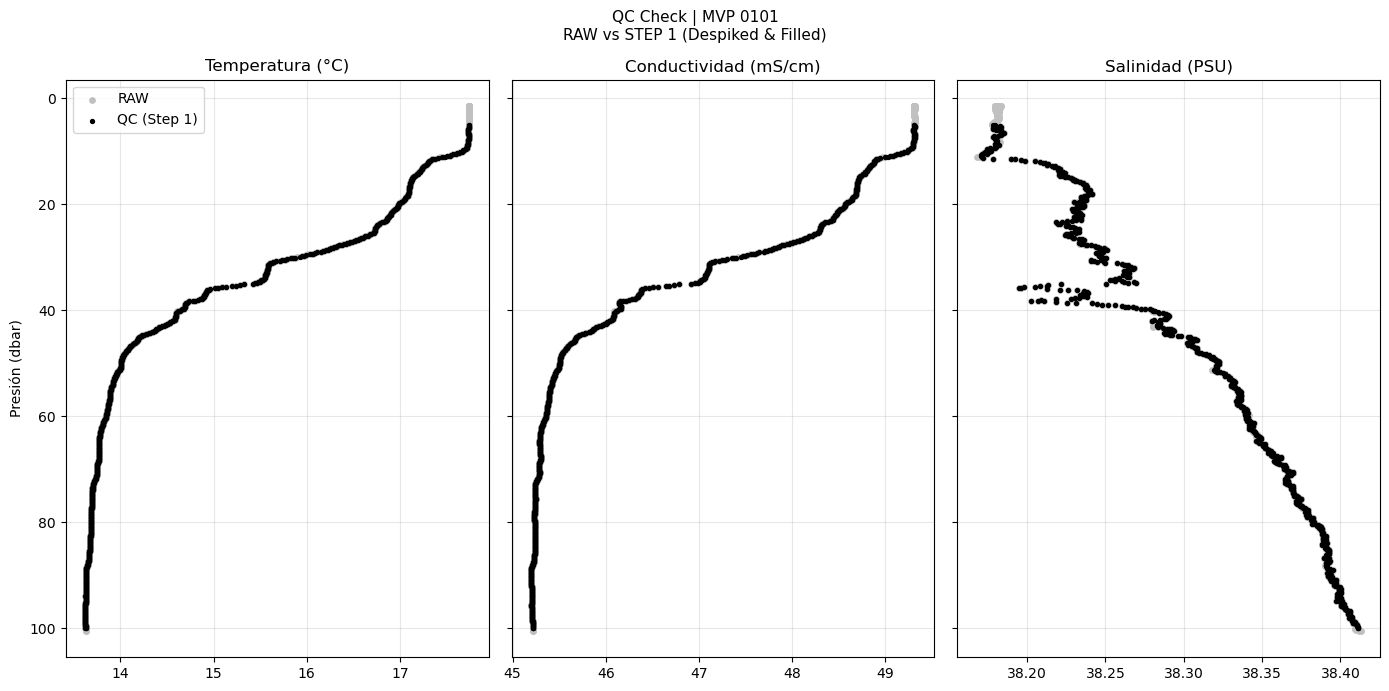

✅ Figura guardada: QC_Check_MVP_0101.png


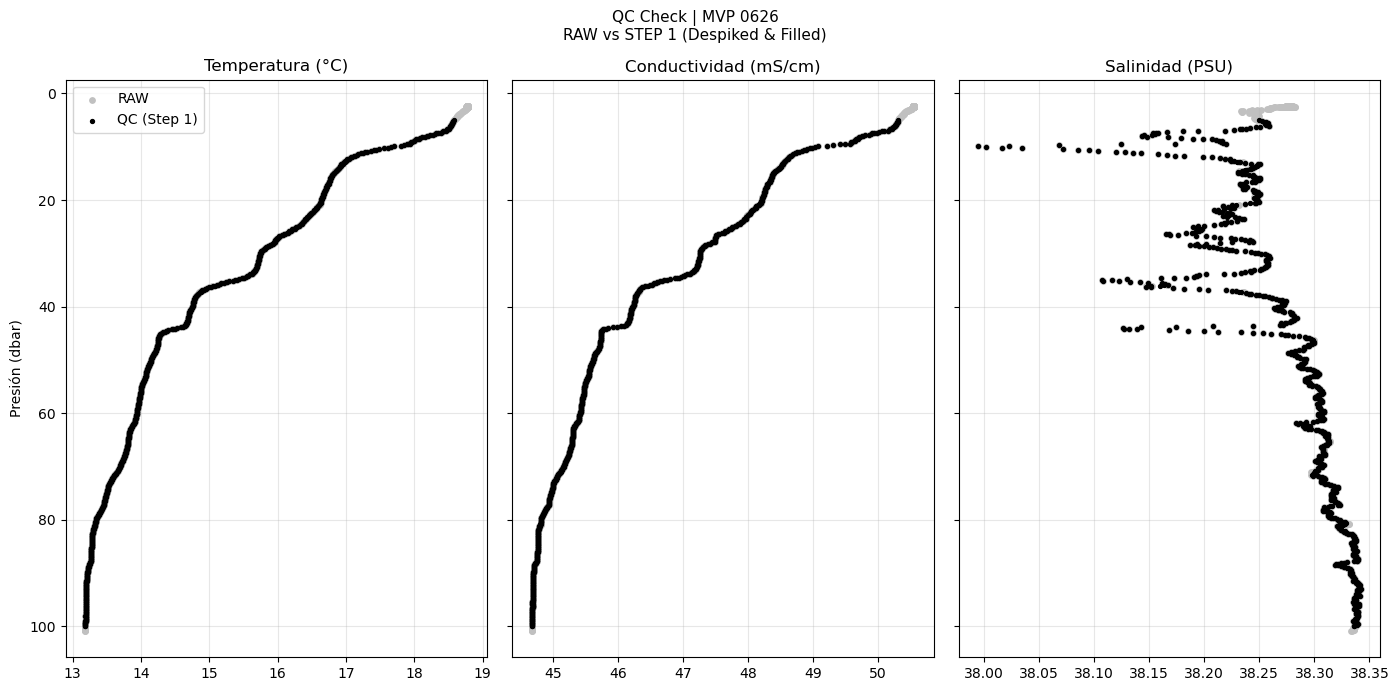

✅ Figura guardada: QC_Check_MVP_0626.png


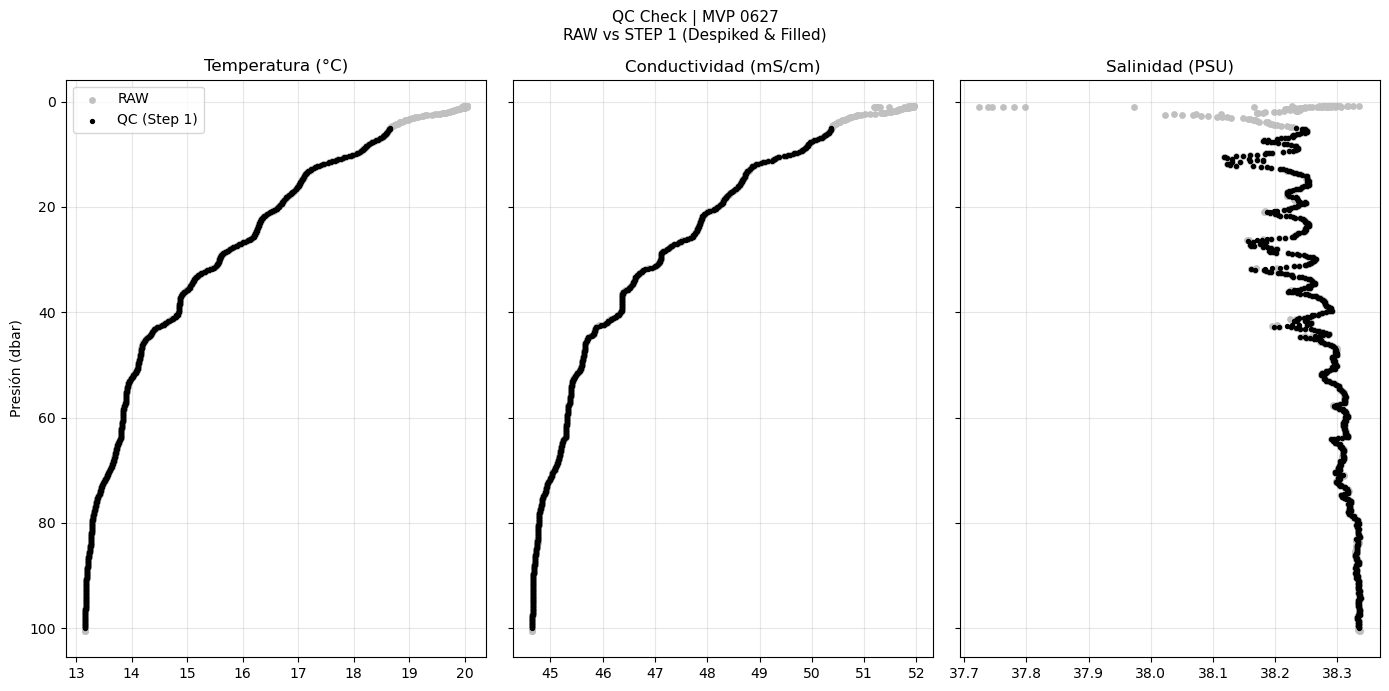

✅ Figura guardada: QC_Check_MVP_0627.png


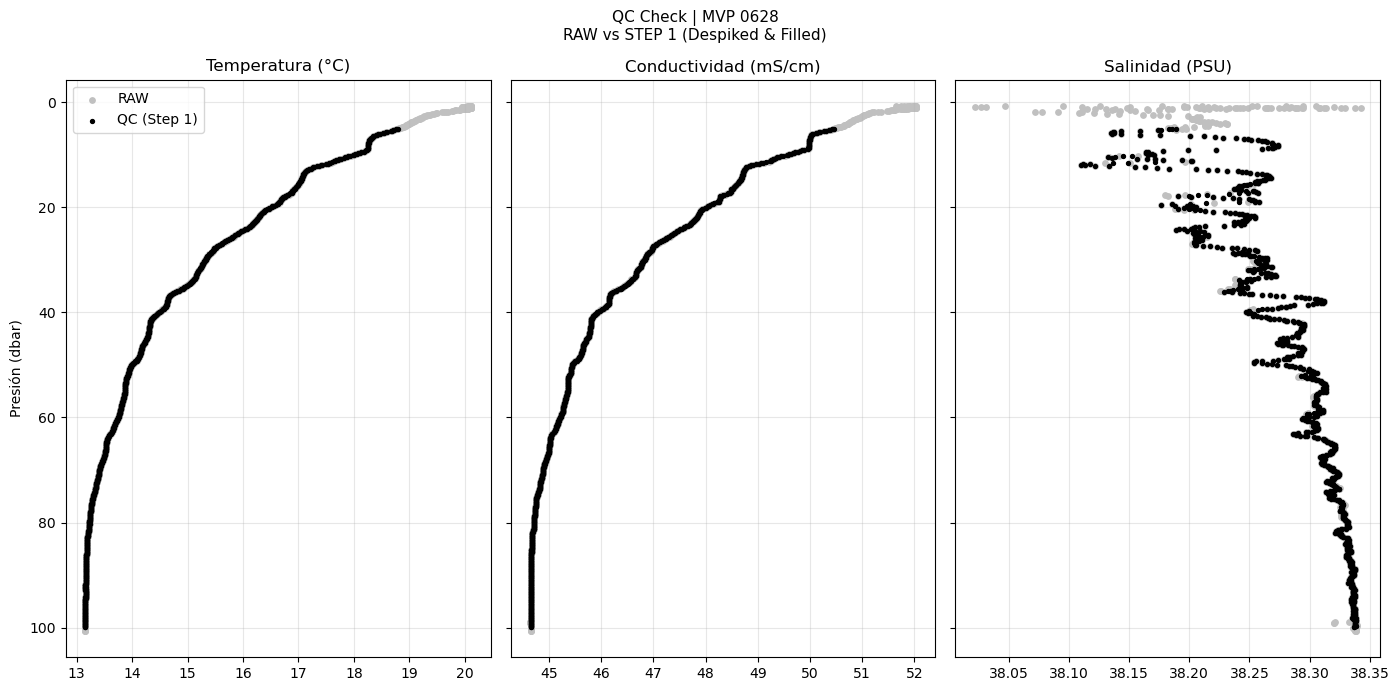

✅ Figura guardada: QC_Check_MVP_0628.png


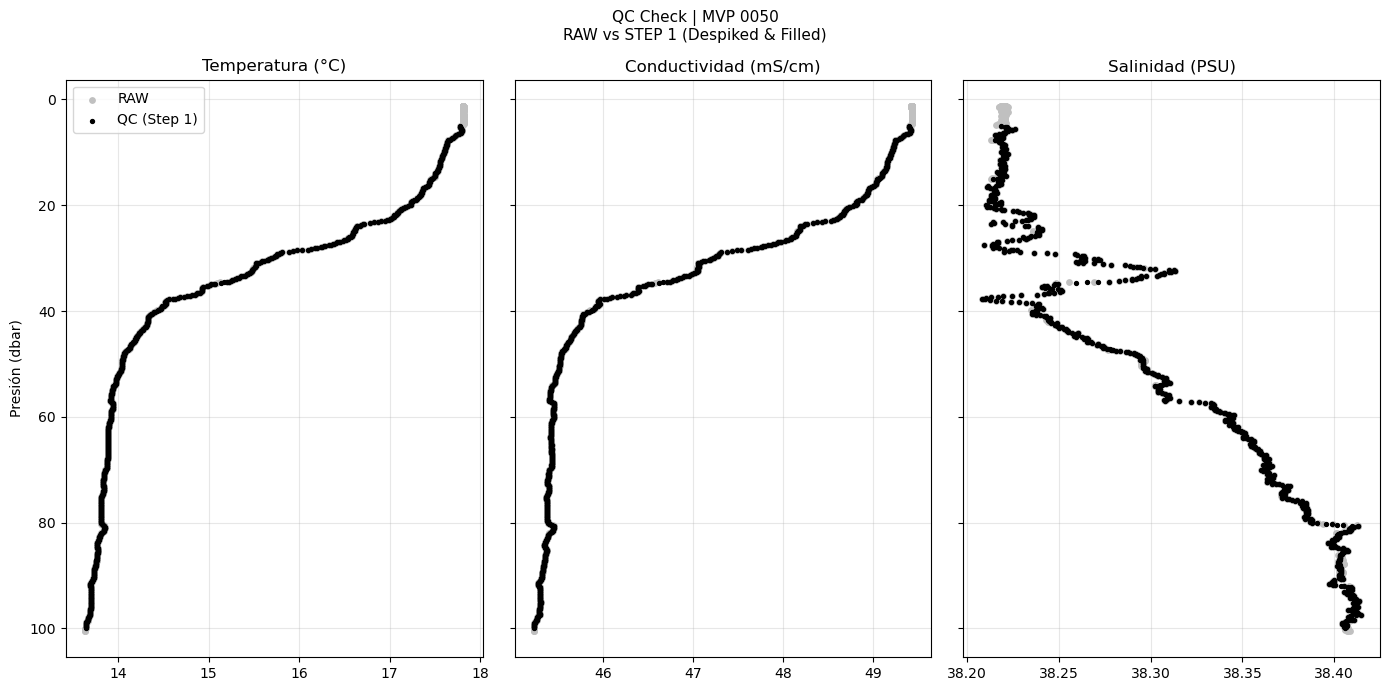

✅ Figura guardada: QC_Check_MVP_0050.png


In [ ]:
# -*- coding: utf-8 -*-
"""
FIGURAS QC: RAW vs STEP1_QC
3 paneles: Temperature, Conductivity, Practical Salinity (SP)

- Compara el archivo RAW (_downcast.nc) con el procesado (_step1_qc.nc).
- Recalcula SIEMPRE SP = gsw.SP_from_C(C, T, p) para comparar peras con peras.
- Permite ver qué spikes se han eliminado y cómo ha rellenado los huecos.
"""

from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import gsw

# =========================
# CONFIGURATION
# =========================
BASE_ROOT = Path(r"C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_fastswot_nc_final_processing")

# Output directory for the validation figures
OUTDIR = BASE_ROOT / "QC_PLOTS_Step1"
OUTDIR.mkdir(parents=True, exist_ok=True)

# IDs of specific profiles to visually inspect
MVP_IDS_TO_CHECK = ["0101", "0626", "0627", "0628", "0050"] 

# Vertical range for the plot (for zooming into the surface layer)
P_MAX_PLOT = 150.0

# =========================
# HELPERS
# =========================
def find_file_pair(mvp_id, base_root):
    """
    Searches for the matching RAW and QC file pair for a given MVP ID,
    checking within both Leg1 and Leg2 directories.
    Returns: (raw_path, qc_path) or (None, None) if not found.
    """
    for leg in ["Leg1", "Leg2"]:
        raw_dir = base_root / leg / "raw"
        qc_dir = base_root / leg / "processed_step1_highres_qc"
        
        # Search patterns
        # Raw files end with _downcast.nc
        # QC files end with _step1_qc.nc
        raw_files = list(raw_dir.glob(f"*{mvp_id}*_downcast.nc"))
        qc_files = list(qc_dir.glob(f"*{mvp_id}*_step1_qc.nc"))
        
        if raw_files and qc_files:
            return raw_files[0], qc_files[0]
            
    return None, None

def get_arrays(ds, max_p):
    """
    Extracts Temperature, Conductivity, and Pressure from the dataset, 
    and calculates Practical Salinity (SP) using the GSW library.
    """
    # Variable name mapping (prioritizes standardized names, falls back to old names)
    if 'pressure' in ds: p = ds.pressure.values
    elif 'Press' in ds: p = ds.Press.values
    else: return None
    
    if 't1' in ds: t = ds.t1.values
    elif 'Temp' in ds: t = ds.Temp.values
    else: return None
    
    if 'c1' in ds: c = ds.c1.values
    elif 'Cond' in ds: c = ds.Cond.values
    else: return None

    # Filter data by maximum depth for plotting and remove Pressure NaNs
    mask = np.isfinite(p) & (p <= max_p)
    p, t, c = p[mask], t[mask], c[mask]
    
    # Calculate Practical Salinity on-the-fly (ensuring correct units)
    # If Conductivity is in S/m (<10), convert it to mS/cm
    c_gsw = c * 10.0 if np.nanmean(c) < 10 else c
    
    sp = gsw.SP_from_C(c_gsw, t, p)
    
    return p, t, c_gsw, sp

# =========================
# PLOTTING
# =========================
def plot_comparison(raw_path, qc_path, out_file):
    ds_r = xr.open_dataset(raw_path)
    ds_q = xr.open_dataset(qc_path)
    
    res_r = get_arrays(ds_r, P_MAX_PLOT)
    res_q = get_arrays(ds_q, P_MAX_PLOT)
    
    ds_r.close()
    ds_q.close()
    
    if not res_r or not res_q:
        print(f"⚠️ Error reading variables from {raw_path.name}")
        return

    pr, tr, cr, sr = res_r
    pq, tq, cq, sq = res_q
    
    # Create Figure
    fig, axs = plt.subplots(1, 3, figsize=(14, 7), sharey=True)
    
    # Common scatter plot styling
    scatter_kw_raw = {'s': 15, 'color': 'silver', 'label': 'RAW', 'zorder': 1}
    scatter_kw_qc  = {'s': 8,  'color': 'k',      'label': 'QC (Step 1)', 'zorder': 2}
    
    # 1. Temperature Panel
    axs[0].scatter(tr, pr, **scatter_kw_raw)
    axs[0].scatter(tq, pq, **scatter_kw_qc)
    axs[0].set_title("Temperature (°C)")
    axs[0].set_ylabel("Pressure (dbar)")
    axs[0].invert_yaxis()
    axs[0].grid(True, alpha=0.3)
    axs[0].legend()
    
    # 2. Conductivity Panel
    axs[1].scatter(cr, pr, **scatter_kw_raw)
    axs[1].scatter(cq, pq, **scatter_kw_qc)
    axs[1].set_title("Conductivity (mS/cm)")
    axs[1].grid(True, alpha=0.3)
    
    # 3. Salinity Panel
    # Outliers removed during QC are visible as the gray points that lack a black overlay
    axs[2].scatter(sr, pr, **scatter_kw_raw)
    axs[2].scatter(sq, pq, **scatter_kw_qc)
    axs[2].set_title("Practical Salinity (PSU)")
    axs[2].grid(True, alpha=0.3)
    
    # Title
    mid = raw_path.stem.split('_')[3] if 'mvp' in raw_path.stem else raw_path.stem
    plt.suptitle(f"QC Check | MVP {mid}\nRAW vs STEP 1 (Despiked & Filled)", fontsize=11)
    
    plt.tight_layout()
    plt.savefig(out_file, dpi=150)
    plt.show()
    print(f"✅ Figure saved: {out_file.name}")

# =========================
# MAIN LOOP
# =========================
print(f"Searching for profiles: {MVP_IDS_TO_CHECK}")

for mid in MVP_IDS_TO_CHECK:
    raw_f, qc_f = find_file_pair(mid, BASE_ROOT)
    
    if raw_f and qc_f:
        out_name = OUTDIR / f"QC_Check_MVP_{mid}.png"
        plot_comparison(raw_f, qc_f, out_name)
    else:
        print(f"❌ Could not find matching file pair for MVP {mid}")